In [1]:
import pandas as pd
import torch as tf

In [2]:
path = "/Users/paulairabor/Documents/year4-sem2/deep/credit_risk_dataset.csv"
df = pd.read_csv(path)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
import numpy as np

# Before one-hot encoding, handle missing values.
# We will fill NaNs in numerical columns with the mean of the respective columns.
# Based on the error, 'loan_int_rate' and 'person_emp_length' are likely candidates.

for col in ['person_emp_length', 'loan_int_rate']:
    if col in df.columns:
        # Convert column to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill NaNs with the mean of the column
        if df[col].isnull().any(): # Only fill if NaNs are present
            df[col] = df[col].fillna(df[col].mean())
            
df = pd.get_dummies(df, drop_first=True)
print(df.head())

   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0          22          59000              123.0      35000          16.02   
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   

   loan_status  loan_percent_income  cb_person_cred_hist_length  \
0            1                 0.59                           3   
1            0                 0.10                           2   
2            1                 0.57                           3   
3            1                 0.53                           2   
4            1                 0.55                           4   

   person_home_ownership_OTHER  person_home_ownership_OWN  ...  \
0                        False                      False  ...   
1 

In [4]:
data = pd.DataFrame(df)
data

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,26,False,False,...,False,True,False,True,False,False,False,False,False,False


In [5]:

#separate features and target (adjust target name if needed)
X = df.drop("loan_status", axis=1).values
y = df["loan_status"].values

In [6]:
X = X.astype(float) # Convert boolean and other compatible types to float
X = tf.tensor(X, dtype=tf.float32)
y = tf.tensor(y, dtype=tf.float32)

In [7]:
X.shape

torch.Size([32581, 22])

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
                                        X, y, test_size=0.2, random_state=42
                                    )

In [9]:
X_train, X_test, y_train, y_test

(tensor([[6.4000e+01, 4.6000e+04, 2.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          1.0000e+00],
         [2.6000e+01, 2.6000e+04, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [2.3000e+01, 5.1000e+04, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          1.0000e+00],
         ...,
         [2.6000e+01, 1.4800e+05, 1.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [2.6000e+01, 1.7500e+05, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [2.7000e+01, 6.5000e+04, 1.1000e+01,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00]]),
 tensor([[2.4000e+01, 2.8000e+04, 6.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [2.7000e+01, 6.4000e+04, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
          1.0000e+00],
         [2.6000e+01, 7.2000e+04, 1.0000e+01,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         ...,
         [2.3000e+01, 1.1400e+05, 4.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
   

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
X_train

array([[ 5.66851795, -0.31717677, -0.68784054, ..., -0.08523743,
        -0.0438411 ,  2.17447733],
       [-0.27606233, -0.63165151, -1.18139371, ..., -0.08523743,
        -0.0438411 , -0.45988063],
       [-0.7453713 , -0.23855808, -0.44106396, ..., -0.08523743,
        -0.0438411 ,  2.17447733],
       ...,
       [-0.27606233,  1.28664442, -0.93461713, ..., -0.08523743,
        -0.0438411 , -0.45988063],
       [-0.27606233,  1.71118532, -1.18139371, ..., -0.08523743,
        -0.0438411 , -0.45988063],
       [-0.11962601, -0.01842576,  1.53314872, ..., -0.08523743,
        -0.0438411 , -0.45988063]])

In [12]:
y_train

tensor([0., 1., 0.,  ..., 1., 0., 0.])

In [13]:
X_train = tf.tensor(X_train, dtype=tf.float32)
X_test = tf.tensor(X_test, dtype=tf.float32)
y_train = tf.tensor(y_train, dtype=tf.float32).view(-1, 1)
y_test = tf.tensor(y_test, dtype=tf.float32).view(-1, 1)

/var/folders/yk/mvxkg43102j_m699g84x_x8m0000gp/T/ipykernel_3266/470016178.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = tf.tensor(y_train, dtype=tf.float32).view(-1, 1)
/var/folders/yk/mvxkg43102j_m699g84x_x8m0000gp/T/ipykernel_3266/470016178.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = tf.tensor(y_test, dtype=tf.float32).view(-1, 1)


In [14]:
X_train.shape

torch.Size([26064, 22])

In [15]:
y_train.shape

torch.Size([26064, 1])

In [16]:
from torch.utils.data import DataLoader, TensorDataset

In [17]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [18]:
train_dataset

In [19]:
train_dataset[20000]

(tensor([-0.9018, -0.5059, -1.1814,  1.0132,  0.7260,  2.7999, -0.6948, -0.0565,
         -0.2939,  0.9910,  2.0166, -0.3528, -0.4777, -0.4529, -0.4593, -0.6889,
         -0.4973,  2.8279, -0.1730, -0.0852, -0.0438, -0.4599]),
 tensor([1.]))

In [20]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [21]:
len(train_loader)

815

In [22]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 22])
torch.Size([32, 1])


In [23]:
first_batch = next(iter(train_loader))
X_batch, y_batch = first_batch

In [24]:
X_batch.shape, y_batch.shape

(torch.Size([32, 22]), torch.Size([32, 1]))

In [25]:
import torch.nn as nn

In [26]:
class CreditRiskModel(nn.Module):
    def __init__(self, input_size):
        super(CreditRiskModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

In [27]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [28]:
device = tf.device("cuda" if tf.cuda.is_available() else "cpu")
device

device(type='cpu')

In [29]:
from torchinfo import summary
input_size = X_train.shape[1]
model = CreditRiskModel(input_size).to(device=device)
summary(model, input_size=(32, input_size), device="cuda" if tf.cuda.is_available() else "cpu")

Layer (type:depth-idx)                   Output Shape              Param #
CreditRiskModel                          [32, 1]                   --
├─Linear: 1-1                            [32, 16]                  368
├─ReLU: 1-2                              [32, 16]                  --
├─Linear: 1-3                            [32, 8]                   136
├─ReLU: 1-4                              [32, 8]                   --
├─Linear: 1-5                            [32, 1]                   9
├─Sigmoid: 1-6                           [32, 1]                   --
Total params: 513
Trainable params: 513
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

In [30]:
print(model)

CreditRiskModel(
  (fc1): Linear(in_features=22, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [31]:
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

fc1.weight: torch.Size([16, 22])
fc1.bias: torch.Size([16])
fc2.weight: torch.Size([8, 16])
fc2.bias: torch.Size([8])
fc3.weight: torch.Size([1, 8])
fc3.bias: torch.Size([1])


In [32]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 513


In [33]:
class EarlyStopping:
    def __init__(self, patience=5, mode='min', verbose=False):
        self.patience = patience
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    def __call__(self, value):
        score = -value if self.mode == 'min' else value
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [36]:
import torch.optim as optim
from sklearn.metrics import (
confusion_matrix,
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score
)

In [37]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Forward pass
        probs = model(X_batch)
        # Loss
        loss = loss_fn(probs, y_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
        preds = (probs >= 0.5).float()
        all_labels.extend(y_batch.detach().cpu().numpy().flatten())
        all_preds.extend(preds.detach().cpu().numpy().flatten())
        all_probs.extend(probs.detach().cpu().numpy().flatten())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    metrics = {
                "accuracy": accuracy_score(all_labels, all_preds) * 100,
                "precision": precision_score(all_labels, all_preds, zero_division=0),
                "recall": recall_score(all_labels, all_preds, zero_division=0),
                "f1": f1_score(all_labels, all_preds, zero_division=0),
                "overall_roc_auc": roc_auc_score(all_labels, all_probs),
                "confusion_matrix": confusion_matrix(all_labels, all_preds)
                }
    return epoch_loss, metrics

In [38]:
def test_step(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with tf.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            probs = model(X_batch)
            loss = loss_fn(probs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            preds = (probs >= 0.5).float()
            all_labels.extend(y_batch.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    
    metrics = {
                "accuracy": accuracy_score(all_labels, all_preds) * 100,
                "precision": precision_score(all_labels, all_preds, zero_division=0),
                "recall": recall_score(all_labels, all_preds, zero_division=0),
                "f1": f1_score(all_labels, all_preds, zero_division=0),
                "overall_roc_auc": roc_auc_score(all_labels, all_probs),
                "confusion_matrix": confusion_matrix(all_labels, all_preds)
                }
    
    return epoch_loss, metrics

In [39]:
from tqdm import tqdm

def train(model, train_dataloader, val_dataloader, optimizer, loss_fn,
    epochs, device, class_names, patience):
    # early_stopping = EarlyStopping(patience=patience, mode='min', verbose=True)
    history = {
                "train_loss": [],
                "val_loss": [],
                "train_metrics": [],
                "val_metrics": []
                }
    model.to(device)
    for epoch in tqdm(range(epochs)):
        train_loss, train_metrics = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device
        )
        
        val_loss, val_metrics = test_step(
        model=model,
        dataloader=val_dataloader,
        loss_fn=loss_fn,
        device=device
        )
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metrics"].append(train_metrics)
        history["val_metrics"].append(val_metrics)
        print(f"\nEpoch: {epoch+1}/{epochs}")

        print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_metrics['accuracy']:.2f}% | "
        f"Precision: {train_metrics['precision']:.4f} | "
        f"Recall: {train_metrics['recall']:.4f} | "
        f"F1 Score: {train_metrics['f1']:.4f} | "
        f"ROC AUC: {train_metrics['overall_roc_auc']:.4f}"
        )
        print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_metrics['accuracy']:.2f}% | "
        f"Precision: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"F1 Score: {val_metrics['f1']:.4f} | "
        f"ROC AUC: {val_metrics['overall_roc_auc']:.4f}"
        )
        # early_stopping(val_loss)
        # if early_stopping.early_stop:
        # print("Early stopping triggered. Training halted.")
        # break
    final_val_metrics = history["val_metrics"][-1]
    conf_matrix = final_val_metrics["confusion_matrix"]
    print("\nFinal Validation Confusion Matrix:")
    plot_confusion_matrix(conf_matrix, class_names)
    return model, history

In [40]:
device = tf.device("cuda" if tf.cuda.is_available() else "cpu")
input_size = X_train.shape[1]
model = CreditRiskModel(input_size)
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
class_names = ["No Default", "Default"]
epochs_num =10

 10%|███▊                                  | 1/10 [00:00<00:08,  1.00it/s]


Epoch: 1/10
Train Loss: 0.3980 | Train Accuracy: 81.57% | Precision: 0.5979 | Recall: 0.4635 | F1 Score: 0.5222 | ROC AUC: 0.8237
Val Loss: 0.3232 | Val Accuracy: 87.46% | Precision: 0.7897 | Recall: 0.5924 | F1 Score: 0.6769 | ROC AUC: 0.8815


 20%|███████▌                              | 2/10 [00:01<00:07,  1.14it/s]


Epoch: 2/10
Train Loss: 0.3068 | Train Accuracy: 88.34% | Precision: 0.8145 | Recall: 0.6002 | F1 Score: 0.6911 | ROC AUC: 0.8887
Val Loss: 0.3071 | Val Accuracy: 88.17% | Precision: 0.8453 | Recall: 0.5709 | F1 Score: 0.6815 | ROC AUC: 0.8904


 30%|███████████▍                          | 3/10 [00:02<00:05,  1.20it/s]

...


Epoch: 8/10
Train Loss: 0.2538 | Train Accuracy: 91.27% | Precision: 0.9031 | Recall: 0.6700 | F1 Score: 0.7693 | ROC AUC: 0.9150
Val Loss: 0.2671 | Val Accuracy: 90.66% | Precision: 0.8885 | Recall: 0.6616 | F1 Score: 0.7584 | ROC AUC: 0.9089


 90%|██████████████████████████████████▏   | 9/10 [00:07<00:00,  1.27it/s]


Epoch: 9/10
Train Loss: 0.2511 | Train Accuracy: 91.38% | Precision: 0.9030 | Recall: 0.6756 | F1 Score: 0.7729 | ROC AUC: 0.9161
Val Loss: 0.2643 | Val Accuracy: 90.89% | Precision: 0.9095 | Recall: 0.6540 | F1 Score: 0.7609 | ROC AUC: 0.9098


100%|█████████████████████████████████████| 10/10 [00:07<00:00,  1.25it/s]


Epoch: 10/10
Train Loss: 0.2483 | Train Accuracy: 91.38% | Precision: 0.9065 | Recall: 0.6728 | F1 Score: 0.7723 | ROC AUC: 0.9175
Val Loss: 0.2664 | Val Accuracy: 90.50% | Precision: 0.8616 | Recall: 0.6810 | F1 Score: 0.7607 | ROC AUC: 0.9103

Final Validation Confusion Matrix:


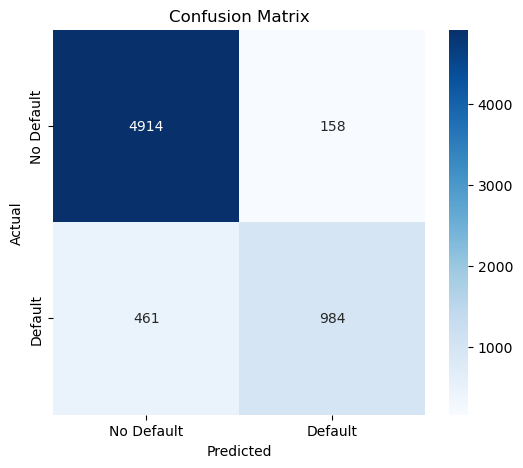

In [41]:
model, history = train(
model=model,
train_dataloader=train_loader,
val_dataloader=test_loader,
optimizer=optimizer,
loss_fn=loss_fn,
epochs= epochs_num,
device=device,
class_names=class_names,
patience=5
)

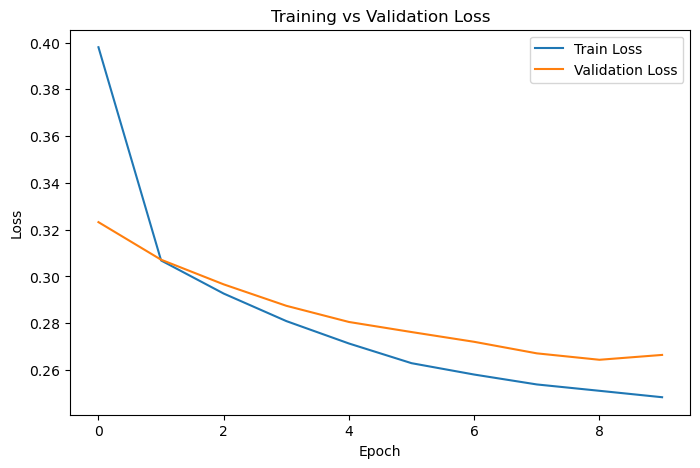

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()